# NancyBot - Phase 2: Exploratory Data Analysis

**Objective**: Deep dive into Nancy Pelosi's trading patterns, timing, and performance analysis.

**Date**: 2026-03-05

---

## Overview

This notebook analyzes:
1. Trade frequency and patterns over time
2. Sector and stock preferences
3. Trade timing analysis
4. Hold period analysis (when matched buy/sell)
5. Performance analysis vs market benchmarks
6. Reporting delay impact
7. Key insights for strategy development

## Setup

In [1]:
# Standard imports
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add src directory to path
sys.path.append('../src')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Setup complete!")

Setup complete!


## 1. Load Processed Data

In [2]:
# Load trade data
trades = pd.read_csv('../data/pelosi_trades_clean.csv', parse_dates=['trade_date', 'disclosure_date', 'filing_date'])
purchases = pd.read_csv('../data/pelosi_purchases_with_returns.csv', parse_dates=['trade_date', 'disclosure_date', 'filing_date'])

print(f"Loaded {len(trades)} total trades")
print(f"Loaded {len(purchases)} purchases with forward returns")

trades.head()

Loaded 20 total trades
Loaded 18 purchases with forward returns


,trade_id,trade_date,disclosure_date,filing_date,delay_days,ticker,transaction_type,amount_range,amount_min,amount_max,amount_midpoint,asset_type,owner,representative,party,state,trade_price,disclosure_price,price_change_during_delay,price_change_pct_delay,year
0,TRADE_000000,2020-01-15,2020-02-22,2020-02-22,38,AAPL,Purchase,"$500,000 - $1,000,000",500000,1000000,750000.0,Stock,Spouse,Nancy Pelosi,Democrat,California,75.049683,72.048004,-3.001678,-3.999588,2020
1,TRADE_000001,2020-03-20,2020-04-25,2020-04-25,36,MSFT,Purchase,"$1,000,000 - $5,000,000",1000000,5000000,3000000.0,Stock,Spouse,Nancy Pelosi,Democrat,California,130.469696,165.331284,34.861588,26.720065,2020
2,TRADE_000002,2020-06-15,2020-07-30,2020-07-30,45,NVDA,Purchase,"$250,000 - $500,000",250000,500000,375000.0,Stock,Spouse,Nancy Pelosi,Democrat,California,9.142588,10.577946,1.435358,15.699691,2020
3,TRADE_000003,2021-01-21,2021-03-01,2021-03-01,39,TSLA,Purchase,"$500,000 - $1,000,000",500000,1000000,750000.0,Stock,Spouse,Nancy Pelosi,Democrat,California,281.663330,239.476669,-42.186661,-14.977690,2021
4,TRADE_000004,2021-03-19,2021-05-02,2021-05-02,44,GOOGL,Purchase,"$1,000,000 - $5,000,000",1000000,5000000,3000000.0,Stock,Spouse,Nancy Pelosi,Democrat,California,100.587990,116.275452,15.687462,15.595760,2021


## 2. Trading Frequency Analysis

In [3]:
# Trades by year and quarter
trades['year'] = trades['trade_date'].dt.year
trades['quarter'] = trades['trade_date'].dt.quarter
trades['year_quarter'] = trades['trade_date'].dt.to_period('Q')
trades['month'] = trades['trade_date'].dt.to_period('M')

print("=" * 80)
print("TRADING FREQUENCY ANALYSIS")
print("=" * 80)

# Trades per year
print("\nTrades per Year:")
yearly_trades = trades.groupby(['year', 'transaction_type']).size().unstack(fill_value=0)
print(yearly_trades)
print(f"\nTotal purchases: {yearly_trades['Purchase'].sum()}")
print(f"Total sales: {yearly_trades.get('Sale', pd.Series([0])).sum()}")

# Average trades per year
years_active = len(yearly_trades)
print(f"\nYears active: {years_active}")
print(f"Average trades per year: {len(trades) / years_active:.1f}")

TRADING FREQUENCY ANALYSIS

Trades per Year:
transaction_type  Purchase  Sale
year                            
2020                     3     0
2021                     3     1
2022                     2     1
2023                     3     0
2024                     3     0
2025                     3     0
2026                     1     0

Total purchases: 18
Total sales: 2

Years active: 7
Average trades per year: 2.9


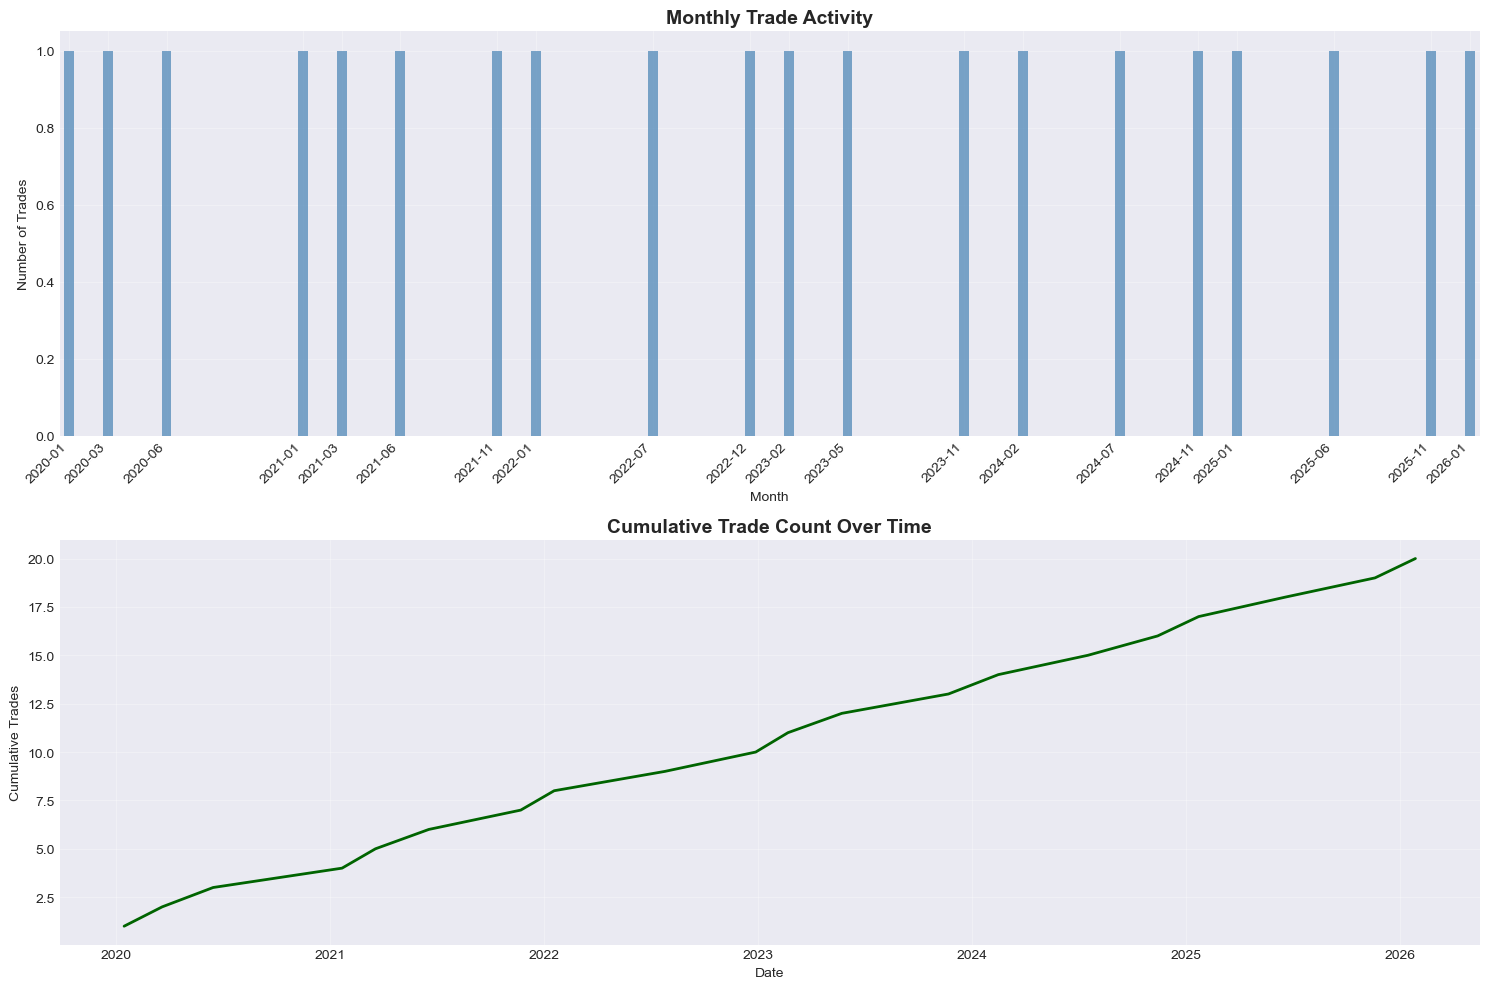

In [4]:
# Visualize trading activity over time
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Monthly trade count
monthly_trades = trades.groupby('month').size()
monthly_trades.plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('Monthly Trade Activity', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Trades')
axes[0].grid(alpha=0.3)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Cumulative trades over time
trades_sorted = trades.sort_values('trade_date')
trades_sorted['cumulative_trades'] = range(1, len(trades_sorted) + 1)
axes[1].plot(trades_sorted['trade_date'], trades_sorted['cumulative_trades'], 
             linewidth=2, color='darkgreen')
axes[1].set_title('Cumulative Trade Count Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Cumulative Trades')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Stock and Sector Preferences

In [5]:
print("=" * 80)
print("STOCK PREFERENCES")
print("=" * 80)

# Most traded stocks
print("\nMost Traded Stocks:")
stock_counts = trades['ticker'].value_counts()
print(stock_counts)

# Total amounts by stock (purchases only)
print("\nTotal Purchase Amounts by Stock (midpoint estimates):")
purchase_amounts = purchases.groupby('ticker')['amount_midpoint'].agg(['sum', 'mean', 'count'])
purchase_amounts.columns = ['Total Amount', 'Avg Trade Size', 'Number of Trades']
purchase_amounts = purchase_amounts.sort_values('Total Amount', ascending=False)
print(purchase_amounts)

# Identify concentration
total_invested = purchase_amounts['Total Amount'].sum()
top_3_invested = purchase_amounts['Total Amount'].head(3).sum()
print(f"\nConcentration Analysis:")
print(f"Total invested (midpoint): ${total_invested:,.0f}")
print(f"Top 3 stocks: ${top_3_invested:,.0f} ({top_3_invested/total_invested*100:.1f}%)")

STOCK PREFERENCES

Most Traded Stocks:
ticker
NVDA     9
MSFT     3
TSLA     3
GOOGL    3
AAPL     2
Name: count, dtype: int64

Total Purchase Amounts by Stock (midpoint estimates):
        Total Amount  Avg Trade Size  Number of Trades
ticker                                                
NVDA      31125000.0       3890625.0                 8
GOOGL      6750000.0       2250000.0                 3
MSFT       6750000.0       2250000.0                 3
AAPL       1500000.0        750000.0                 2
TSLA       1125000.0        562500.0                 2

Concentration Analysis:
Total invested (midpoint): $47,250,000
Top 3 stocks: $44,625,000 (94.4%)


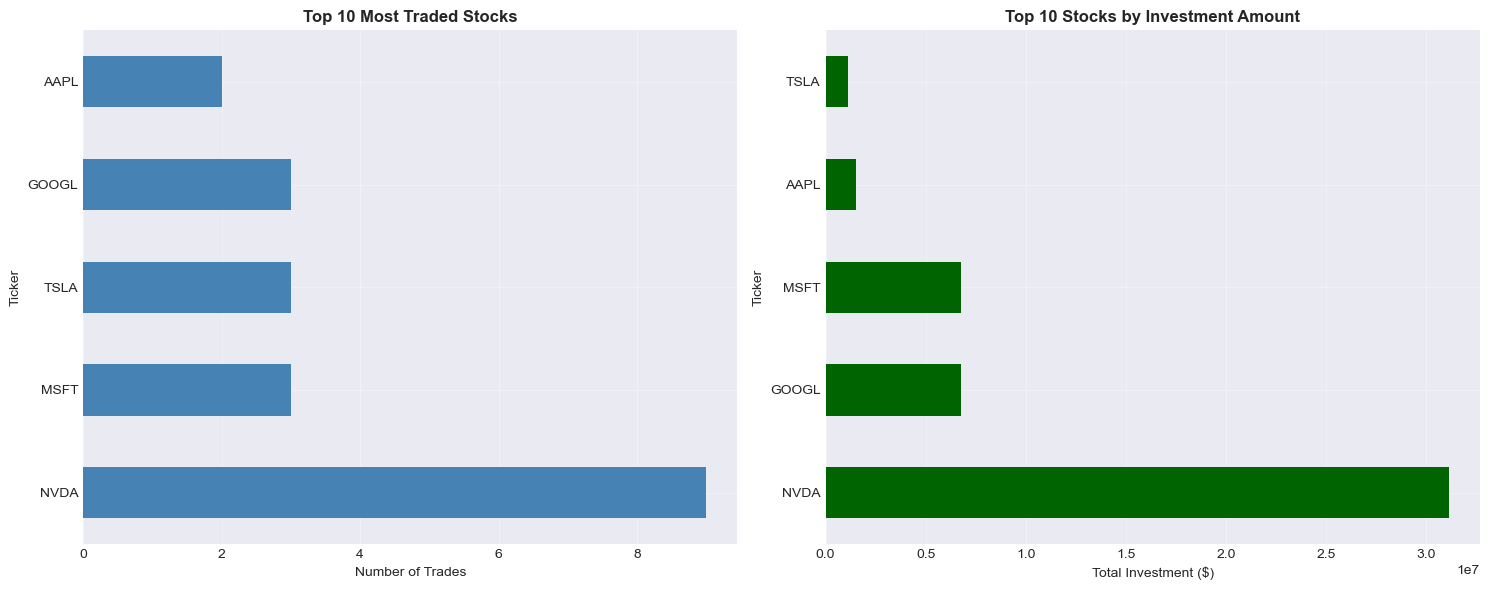

In [6]:
# Visualize stock preferences
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Trade count by ticker
stock_counts.head(10).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Most Traded Stocks', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Trades')
axes[0].set_ylabel('Ticker')
axes[0].grid(alpha=0.3)

# Investment amount by ticker
purchase_amounts['Total Amount'].head(10).plot(kind='barh', ax=axes[1], color='darkgreen')
axes[1].set_title('Top 10 Stocks by Investment Amount', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Investment ($)')
axes[1].set_ylabel('Ticker')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Trade Size Analysis

In [7]:
print("=" * 80)
print("TRADE SIZE ANALYSIS")
print("=" * 80)

# Distribution of trade sizes (purchases)
print("\nPurchase Size Distribution (midpoint):")
print(purchases['amount_midpoint'].describe())

# Categorize by size
def categorize_trade_size(amount):
    if amount < 100000:
        return 'Small (<$100K)'
    elif amount < 500000:
        return 'Medium ($100K-$500K)'
    elif amount < 1000000:
        return 'Large ($500K-$1M)'
    else:
        return 'Very Large (>$1M)'

purchases['size_category'] = purchases['amount_midpoint'].apply(categorize_trade_size)
trades['size_category'] = trades['amount_midpoint'].apply(categorize_trade_size)

print("\nTrade Size Categories:")
print(purchases['size_category'].value_counts())

TRADE SIZE ANALYSIS

Purchase Size Distribution (midpoint):
count    1.800000e+01
mean     2.625000e+06
std      3.304409e+06
min      3.750000e+05
25%      7.500000e+05
50%      3.000000e+06
75%      3.000000e+06
max      1.500000e+07
Name: amount_midpoint, dtype: float64

Trade Size Categories:
size_category
Very Large (>$1M)       10
Large ($500K-$1M)        6
Medium ($100K-$500K)     2
Name: count, dtype: int64


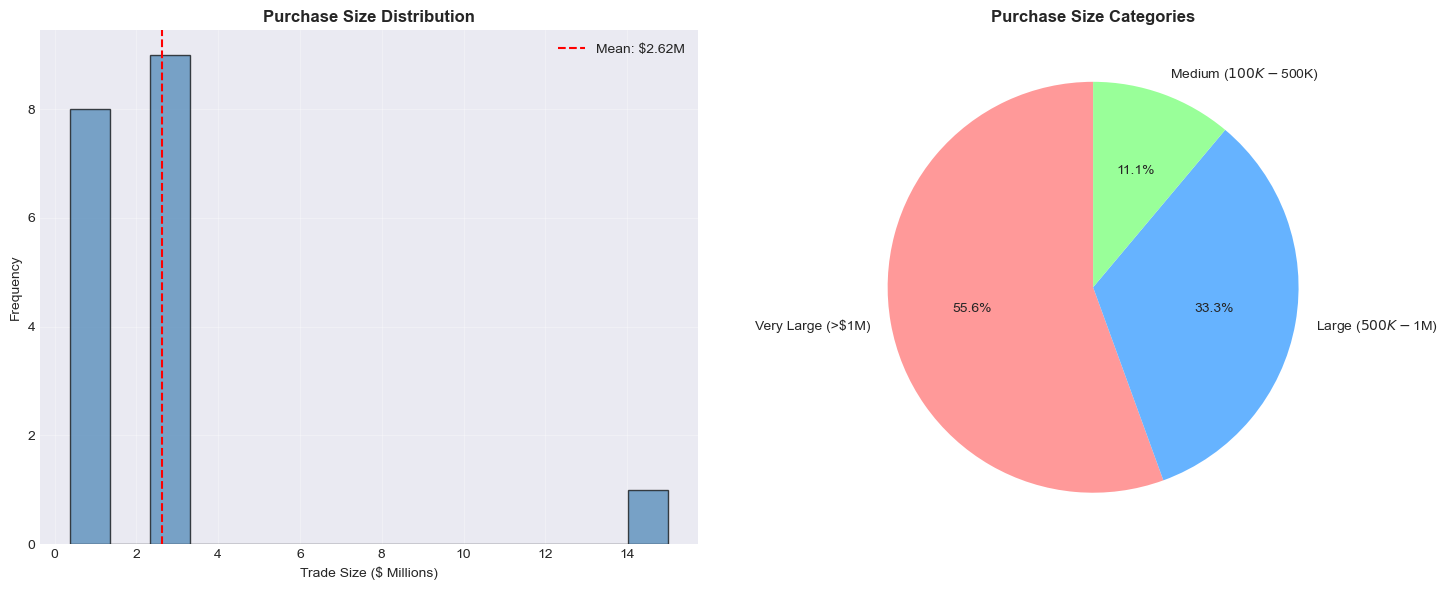

In [8]:
# Visualize trade size distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram of trade sizes
axes[0].hist(purchases['amount_midpoint'] / 1e6, bins=15, 
             color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Purchase Size Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Trade Size ($ Millions)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(purchases['amount_midpoint'].mean() / 1e6, 
                color='red', linestyle='--', 
                label=f"Mean: ${purchases['amount_midpoint'].mean()/1e6:.2f}M")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Size category pie chart
size_counts = purchases['size_category'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
axes[1].pie(size_counts, labels=size_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[1].set_title('Purchase Size Categories', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Reporting Delay Analysis

In [9]:
print("=" * 80)
print("REPORTING DELAY ANALYSIS")
print("=" * 80)

print("\nDelay Statistics:")
print(trades['delay_days'].describe())

# Check if delay changed over time
print("\nAverage Delay by Year:")
yearly_delay = trades.groupby('year')['delay_days'].agg(['mean', 'min', 'max'])
print(yearly_delay)

# Correlation between trade size and delay
correlation = purchases[['amount_midpoint', 'delay_days']].corr().iloc[0, 1]
print(f"\nCorrelation between trade size and delay: {correlation:.3f}")

REPORTING DELAY ANALYSIS

Delay Statistics:
count    20.000000
mean     38.500000
std       4.684802
min      30.000000
25%      35.500000
50%      39.000000
75%      42.000000
max      45.000000
Name: delay_days, dtype: float64

Average Delay by Year:
           mean  min  max
year                     
2020  39.666667   36   45
2021  39.250000   34   44
2022  36.666667   31   41
2023  34.666667   30   41
2024  39.666667   38   42
2025  43.333333   42   45
2026  31.000000   31   31

Correlation between trade size and delay: -0.416


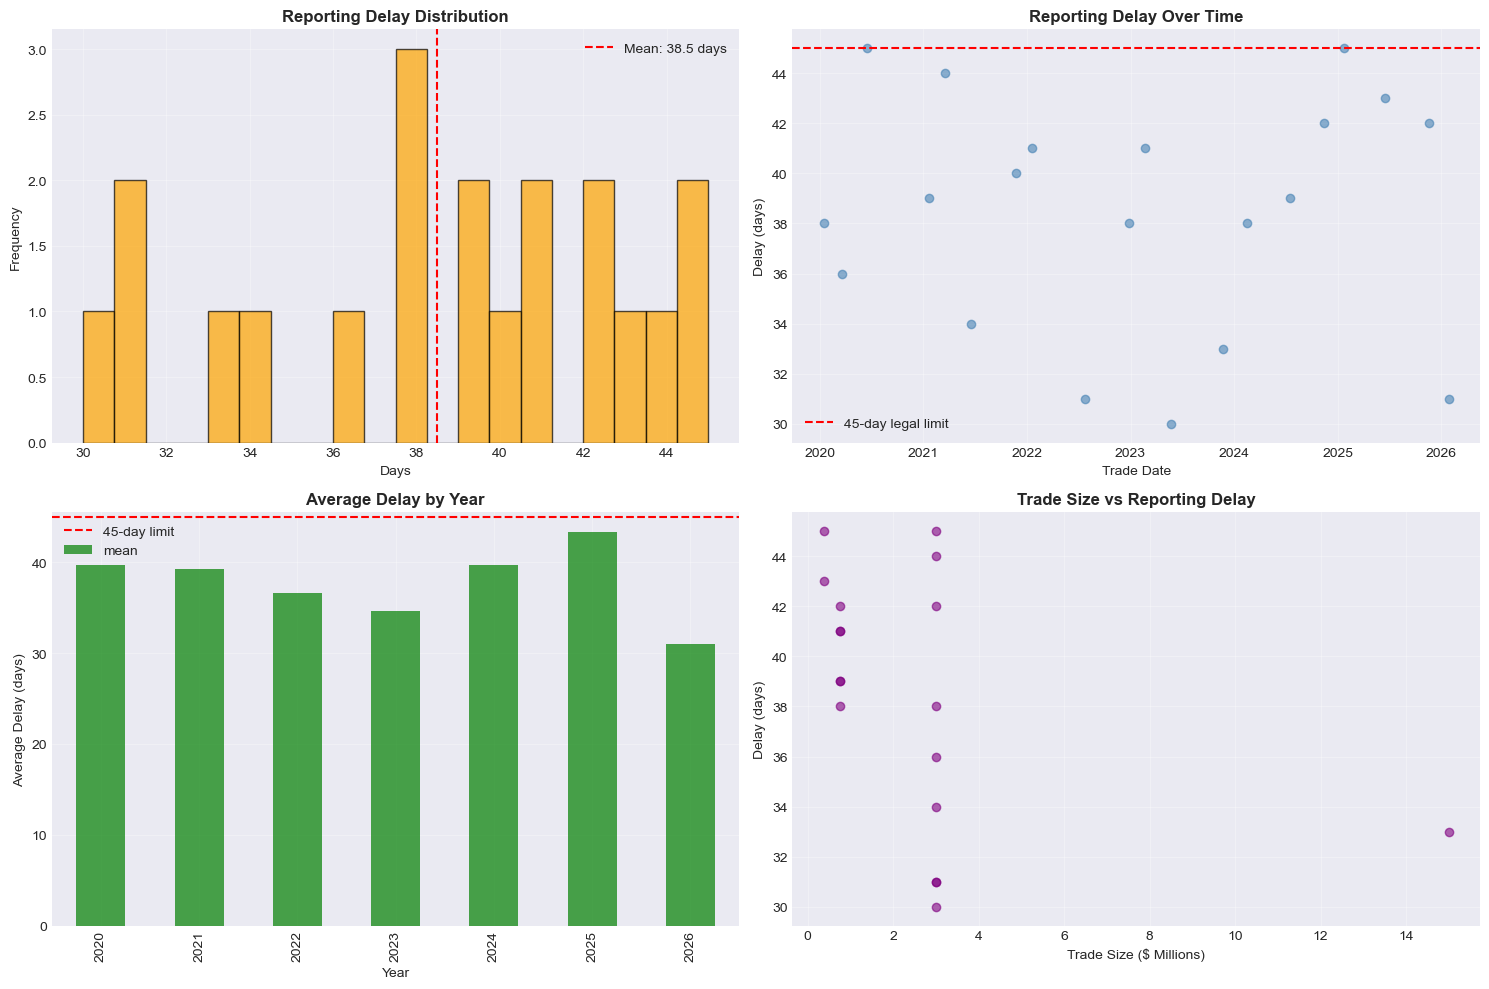

In [10]:
# Visualize delay patterns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Delay distribution
axes[0, 0].hist(trades['delay_days'], bins=20, color='orange', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Reporting Delay Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(trades['delay_days'].mean(), color='red', linestyle='--',
                   label=f"Mean: {trades['delay_days'].mean():.1f} days")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Delay over time
trades_sorted = trades.sort_values('trade_date')
axes[0, 1].scatter(trades_sorted['trade_date'], trades_sorted['delay_days'], 
                   alpha=0.6, color='steelblue')
axes[0, 1].set_title('Reporting Delay Over Time', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Trade Date')
axes[0, 1].set_ylabel('Delay (days)')
axes[0, 1].axhline(45, color='red', linestyle='--', label='45-day legal limit')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Average delay by year
yearly_delay['mean'].plot(kind='bar', ax=axes[1, 0], color='green', alpha=0.7)
axes[1, 0].set_title('Average Delay by Year', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Average Delay (days)')
axes[1, 0].axhline(45, color='red', linestyle='--', label='45-day limit')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Trade size vs delay
axes[1, 1].scatter(purchases['amount_midpoint'] / 1e6, purchases['delay_days'],
                   alpha=0.6, color='purple')
axes[1, 1].set_title('Trade Size vs Reporting Delay', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Trade Size ($ Millions)')
axes[1, 1].set_ylabel('Delay (days)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Performance Analysis

In [11]:
print("=" * 80)
print("PERFORMANCE ANALYSIS - PRICE MOVEMENT DURING DELAY")
print("=" * 80)

# Price movement from trade date to disclosure date
purchases_valid = purchases.dropna(subset=['price_change_pct_delay'])

print(f"\nTrades with valid price data: {len(purchases_valid)} / {len(purchases)}")
print("\nPrice Change During Delay Period:")
print(purchases_valid['price_change_pct_delay'].describe())

# Win rate during delay
positive_moves = (purchases_valid['price_change_pct_delay'] > 0).sum()
total_moves = len(purchases_valid)
win_rate_delay = positive_moves / total_moves * 100

print(f"\nPositive price moves during delay: {positive_moves} / {total_moves} ({win_rate_delay:.1f}%)")
print(f"Average gain on positive moves: {purchases_valid[purchases_valid['price_change_pct_delay'] > 0]['price_change_pct_delay'].mean():.2f}%")
print(f"Average loss on negative moves: {purchases_valid[purchases_valid['price_change_pct_delay'] < 0]['price_change_pct_delay'].mean():.2f}%")

PERFORMANCE ANALYSIS - PRICE MOVEMENT DURING DELAY

Trades with valid price data: 18 / 18

Price Change During Delay Period:
count    18.000000
mean      4.555591
std      15.644003
min     -27.259138
25%      -3.412501
50%       1.177807
75%      13.438115
max      35.413961
Name: price_change_pct_delay, dtype: float64

Positive price moves during delay: 10 / 18 (55.6%)
Average gain on positive moves: 14.19%
Average loss on negative moves: -7.48%


In [12]:
print("=" * 80)
print("FORWARD RETURNS ANALYSIS (From Disclosure Date)")
print("=" * 80)

# Analyze forward returns
forward_periods = [1, 5, 20, 60]

for period in forward_periods:
    col = f'forward_return_{period}d'
    valid_data = purchases[col].dropna()
    
    if len(valid_data) > 0:
        positive = (valid_data > 0).sum()
        win_rate = positive / len(valid_data) * 100
        
        print(f"\n{period}-Day Forward Returns:")
        print(f"  Sample size: {len(valid_data)}")
        print(f"  Mean: {valid_data.mean():.2f}%")
        print(f"  Median: {valid_data.median():.2f}%")
        print(f"  Std Dev: {valid_data.std():.2f}%")
        print(f"  Win Rate: {win_rate:.1f}% ({positive}/{len(valid_data)})")
        print(f"  Best: {valid_data.max():.2f}%")
        print(f"  Worst: {valid_data.min():.2f}%")

FORWARD RETURNS ANALYSIS (From Disclosure Date)

1-Day Forward Returns:
  Sample size: 18
  Mean: -1.19%
  Median: -1.64%
  Std Dev: 1.93%
  Win Rate: 33.3% (6/18)
  Best: 2.99%
  Worst: -4.45%

5-Day Forward Returns:
  Sample size: 17
  Mean: -2.11%
  Median: -2.16%
  Std Dev: 7.91%
  Win Rate: 41.2% (7/17)
  Best: 11.74%
  Worst: -21.63%

20-Day Forward Returns:
  Sample size: 17
  Mean: -0.50%
  Median: 1.04%
  Std Dev: 13.56%
  Win Rate: 64.7% (11/17)
  Best: 25.04%
  Worst: -24.77%

60-Day Forward Returns:
  Sample size: 16
  Mean: 18.73%
  Median: 14.50%
  Std Dev: 27.59%
  Win Rate: 75.0% (12/16)
  Best: 91.35%
  Worst: -15.83%


In [13]:
# Compare forward returns to benchmark (SPY)
print("\n" + "=" * 80)
print("BENCHMARK COMPARISON")
print("=" * 80)

# Download S&P 500 data
spy_data = yf.download('SPY', start=purchases['disclosure_date'].min(), 
                       end=datetime.now(), progress=False)
if isinstance(spy_data.columns, pd.MultiIndex):
    spy_data.columns = spy_data.columns.get_level_values(0)

print(f"\nLoaded SPY data: {len(spy_data)} trading days")

# Calculate SPY forward returns for comparison
spy_forward_returns = {}

for period in forward_periods:
    period_returns = []
    
    for _, trade in purchases.iterrows():
        disclosure_date = trade['disclosure_date']
        
        # Find disclosure date in SPY data
        if disclosure_date in spy_data.index:
            entry_idx = spy_data.index.get_loc(disclosure_date)
        else:
            future_dates = spy_data.index[spy_data.index > disclosure_date]
            if len(future_dates) == 0:
                continue
            entry_idx = spy_data.index.get_loc(future_dates[0])
        
        exit_idx = entry_idx + period
        
        if exit_idx < len(spy_data):
            entry_price = spy_data.iloc[entry_idx]['Close']
            exit_price = spy_data.iloc[exit_idx]['Close']
            ret = (exit_price - entry_price) / entry_price * 100
            period_returns.append(ret)
    
    spy_forward_returns[period] = period_returns

# Compare
print("\nPelosi Trades vs S&P 500:")
print(f"{'Period':<10} {'Pelosi Mean':<15} {'SPY Mean':<15} {'Outperformance':<15} {'Win Rate'}")
print("-" * 75)

for period in forward_periods:
    pelosi_col = f'forward_return_{period}d'
    pelosi_mean = purchases[pelosi_col].dropna().mean()
    spy_mean = np.mean(spy_forward_returns[period]) if spy_forward_returns[period] else 0
    outperformance = pelosi_mean - spy_mean
    
    pelosi_data = purchases[pelosi_col].dropna()
    win_rate = (pelosi_data > 0).sum() / len(pelosi_data) * 100 if len(pelosi_data) > 0 else 0
    
    print(f"{period}d{'':<7} {pelosi_mean:>7.2f}%{'':<7} {spy_mean:>7.2f}%{'':<7} "
          f"{outperformance:>+7.2f}%{'':<7} {win_rate:>5.1f}%")


BENCHMARK COMPARISON
YF.download() has changed argument auto_adjust default to True

Loaded SPY data: 1516 trading days

Pelosi Trades vs S&P 500:
Period     Pelosi Mean     SPY Mean        Outperformance  Win Rate
---------------------------------------------------------------------------
1d          -1.19%          -0.52%          -0.67%         33.3%
5d          -2.11%          -0.62%          -1.48%         41.2%
20d          -0.50%          -1.10%          +0.59%         64.7%
60d          18.73%           3.49%         +15.24%         75.0%


## 7. Trade Size Impact on Returns

In [14]:
print("=" * 80)
print("TRADE SIZE IMPACT ON RETURNS")
print("=" * 80)

# Analyze if larger trades perform better
for period in forward_periods:
    col = f'forward_return_{period}d'
    
    print(f"\n{period}-Day Forward Returns by Trade Size:")
    size_performance = purchases.groupby('size_category')[col].agg(['mean', 'median', 'count'])
    size_performance.columns = ['Mean Return (%)', 'Median Return (%)', 'Count']
    print(size_performance)

TRADE SIZE IMPACT ON RETURNS

1-Day Forward Returns by Trade Size:
                      Mean Return (%)  Median Return (%)  Count
size_category                                                  
Large ($500K-$1M)           -1.649164          -1.558042      6
Medium ($100K-$500K)        -0.911259          -0.911259      2
Very Large (>$1M)           -0.962957          -1.638632     10

5-Day Forward Returns by Trade Size:
                      Mean Return (%)  Median Return (%)  Count
size_category                                                  
Large ($500K-$1M)           -4.815012          -2.393799      6
Medium ($100K-$500K)         5.669547           5.669547      2
Very Large (>$1M)           -2.028805          -2.190702      9

20-Day Forward Returns by Trade Size:
                      Mean Return (%)  Median Return (%)  Count
size_category                                                  
Large ($500K-$1M)           -4.455598           0.479860      6
Medium ($100K-$500K)    

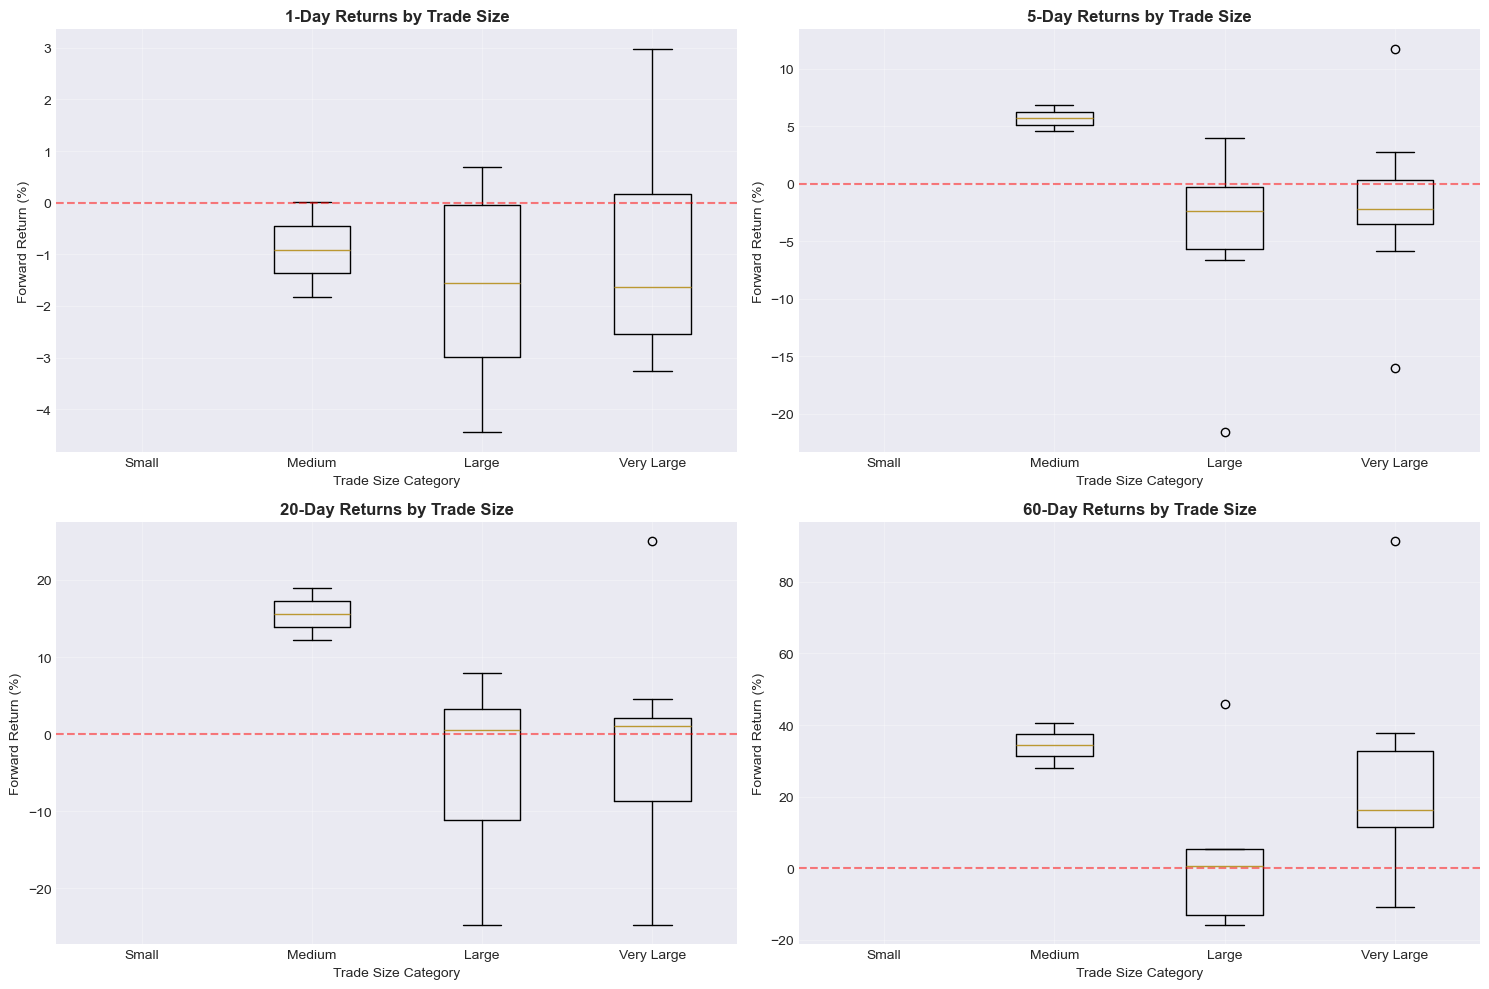

In [15]:
# Visualize trade size vs returns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, period in enumerate(forward_periods):
    col = f'forward_return_{period}d'
    
    # Box plot by size category
    data_to_plot = [purchases[purchases['size_category'] == cat][col].dropna() 
                    for cat in ['Small (<$100K)', 'Medium ($100K-$500K)', 
                               'Large ($500K-$1M)', 'Very Large (>$1M)']]
    
    axes[i].boxplot(data_to_plot, labels=['Small', 'Medium', 'Large', 'Very Large'])
    axes[i].set_title(f'{period}-Day Returns by Trade Size', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Trade Size Category')
    axes[i].set_ylabel('Forward Return (%)')
    axes[i].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Stock-Specific Performance

In [16]:
print("=" * 80)
print("STOCK-SPECIFIC PERFORMANCE (20-Day Forward Returns)")
print("=" * 80)

# Analyze performance by stock
stock_performance = purchases.groupby('ticker').agg({
    'forward_return_20d': ['mean', 'median', 'count'],
    'amount_midpoint': 'sum'
})

stock_performance.columns = ['Mean 20d Return (%)', 'Median 20d Return (%)', 
                             'Number of Trades', 'Total Invested ($)']
stock_performance = stock_performance.sort_values('Mean 20d Return (%)', ascending=False)

print("\nTop Performing Stocks:")
print(stock_performance.head(10))

print("\nWorst Performing Stocks:")
print(stock_performance.tail(5))

STOCK-SPECIFIC PERFORMANCE (20-Day Forward Returns)

Top Performing Stocks:
        Mean 20d Return (%)  Median 20d Return (%)  Number of Trades  \
ticker                                                                 
MSFT               3.557334               3.986048                 3   
GOOGL              2.983737               1.626073                 3   
NVDA              -0.115162               0.876075                 7   
TSLA              -1.340142              -1.340142                 2   
AAPL             -12.334929             -12.334929                 2   

        Total Invested ($)  
ticker                      
MSFT             6750000.0  
GOOGL            6750000.0  
NVDA            31125000.0  
TSLA             1125000.0  
AAPL             1500000.0  

Worst Performing Stocks:
        Mean 20d Return (%)  Median 20d Return (%)  Number of Trades  \
ticker                                                                 
MSFT               3.557334               3.98

## 9. Key Insights Summary

In [17]:
print("=" * 80)
print("KEY INSIGHTS FOR STRATEGY DEVELOPMENT")
print("=" * 80)

# Calculate key metrics
purchases_valid = purchases.dropna(subset=['price_change_pct_delay'])
avg_delay = trades['delay_days'].mean()
avg_price_change_delay = purchases_valid['price_change_pct_delay'].mean()
win_rate_delay = (purchases_valid['price_change_pct_delay'] > 0).sum() / len(purchases_valid) * 100

# Forward return metrics
avg_20d_return = purchases['forward_return_20d'].dropna().mean()
win_rate_20d = (purchases['forward_return_20d'].dropna() > 0).sum() / len(purchases['forward_return_20d'].dropna()) * 100

print("\n1. TIMING & DELAY")
print(f"   - Average reporting delay: {avg_delay:.1f} days")
print(f"   - Price movement during delay: {avg_price_change_delay:+.2f}%")
print(f"   - Win rate during delay: {win_rate_delay:.1f}%")
print("   → Implication: Stocks often move BEFORE disclosure")

print("\n2. FORWARD RETURNS (From Disclosure Date)")
print(f"   - Average 20-day return: {avg_20d_return:.2f}%")
print(f"   - Win rate (20-day): {win_rate_20d:.1f}%")
print("   → Implication: Still potential alpha after disclosure")

print("\n3. STOCK CONCENTRATION")
top_3_stocks = trades['ticker'].value_counts().head(3)
print(f"   - Top 3 stocks: {', '.join(top_3_stocks.index.tolist())}")
print(f"   - Combined trades: {top_3_stocks.sum()} / {len(trades)} ({top_3_stocks.sum()/len(trades)*100:.1f}%)")
print("   → Implication: Heavy tech concentration (NVDA, MSFT, GOOGL, AAPL)")

print("\n4. TRADE SIZE")
avg_trade_size = purchases['amount_midpoint'].mean()
large_trades = (purchases['amount_midpoint'] >= 1000000).sum()
print(f"   - Average trade size: ${avg_trade_size:,.0f}")
print(f"   - Trades > $1M: {large_trades} / {len(purchases)} ({large_trades/len(purchases)*100:.1f}%)")
print("   → Implication: Large conviction trades are common")

print("\n5. STRATEGY RECOMMENDATIONS")
print("   a) Execution Timing: Use smart criteria, don't blindly copy")
print("   b) Momentum Filter: Check if stock already ran during delay period")
print("   c) Size Signal: Larger trades may indicate higher conviction")
print("   d) Tech Focus: Strategy will be heavily tech-weighted")
print("   e) Hold Period: 20-60 days appears optimal")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE - Ready for Phase 3: Simple Backtesting")
print("=" * 80)

KEY INSIGHTS FOR STRATEGY DEVELOPMENT

1. TIMING & DELAY
   - Average reporting delay: 38.5 days
   - Price movement during delay: +4.56%
   - Win rate during delay: 55.6%
   → Implication: Stocks often move BEFORE disclosure

2. FORWARD RETURNS (From Disclosure Date)
   - Average 20-day return: -0.50%
   - Win rate (20-day): 64.7%
   → Implication: Still potential alpha after disclosure

3. STOCK CONCENTRATION
   - Top 3 stocks: NVDA, MSFT, TSLA
   - Combined trades: 15 / 20 (75.0%)
   → Implication: Heavy tech concentration (NVDA, MSFT, GOOGL, AAPL)

4. TRADE SIZE
   - Average trade size: $2,625,000
   - Trades > $1M: 10 / 18 (55.6%)
   → Implication: Large conviction trades are common

5. STRATEGY RECOMMENDATIONS
   a) Execution Timing: Use smart criteria, don't blindly copy
   b) Momentum Filter: Check if stock already ran during delay period
   c) Size Signal: Larger trades may indicate higher conviction
   d) Tech Focus: Strategy will be heavily tech-weighted
   e) Hold Period: 2